In [ ]:
import tensorflow as tf

#Importing the data

# 1. Parameters

image_dir = "/content/sample_data"   # folder containing class subfolders
img_height = 224
img_width = 224
batch_size = 32

# Only use these six specific classes
class_names = [
    "GG0038ON_011",
    "GG0062S_003",
    "GG0131O_001",
    "SL 124_001",
    "SL 552_001",
    "SL M117_003"
]


# 2. Load dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    class_names=class_names
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    image_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    class_names=class_names
)


# 3. Data augmentation pipeline

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(0.2),
], name="data_augmentation")


# 4. Normalize pixels

normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply augmentation + normalization to training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))

# Only apply normalization to validation dataset
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

num_classes = len(class_names)
print("Detected classes:", class_names)

Found 420 files belonging to 6 classes.
Using 336 files for training.
Found 420 files belonging to 6 classes.
Using 84 files for validation.
Detected classes: ['GG0038ON_011', 'GG0062S_003', 'GG0131O_001', 'SL 124_001', 'SL 552_001', 'SL M117_003']


In [ ]:
#inspect class distribution

for class_name in class_names:
    print(class_name)

GG0038ON_011
GG0062S_003
GG0131O_001
SL 124_001
SL 552_001
SL M117_003


In [ ]:
#Build a Multi-Layer CNN for BASE MODEL from scratch


model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(img_height, img_width, 3)),

    # Data augmentation (only applied during training)
    data_augmentation,

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Classification head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes, activation='softmax'),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,978,918 (99.10 MB)

 Trainable params: 25,978,918 (99.10 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the BASE MODEL


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the Model


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 151s 12s/step - accuracy: 0.1675 - loss: 15.3169 - val_accuracy: 0.1786 - val_loss: 1.7927
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 201s 12s/step - accuracy: 0.1472 - loss: 1.8018 - val_accuracy: 0.1429 - val_loss: 1.7920
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 154s 13s/step - accuracy: 0.1941 - loss: 1.7914 - val_accuracy: 0.1548 - val_loss: 1.7927
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 194s 12s/step - accuracy: 0.1481 - loss: 1.7920 - val_accuracy: 0.1548 - val_loss: 1.7929
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 153s 13s/step - accuracy: 0.1613 - loss: 1.7908 - val_accuracy: 0.1548 - val_loss: 1.7935
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 155s 13s/step - accuracy: 0.1889 - loss: 1.7916 - val_accuracy: 0.1548 - val_loss: 1.7936
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 147s 13s/step - accuracy: 0.1228 - loss: 1.7912 - val_accuracy: 0.1548 - val_loss: 1.7939
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 149s 13s/step - accuracy: 0.1530 - loss: 1.7914 - val_accuracy: 0

In [ ]:
# Evaluate


model.evaluate(val_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.1436 - loss: 1.7941


[1.7946504354476929, 0.130952388048172]

In [ ]:
#Transfer Learning 1st Model
#Our first attempt was to unfreeze the last 40 layers of the model, to see if there was benefit to learn from our data.

base_model3 = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model3.trainable = True

for layer in base_model3.layers[:-40]:
    layer.trainable = False

model3 = tf.keras.Sequential([
    tf.keras.layers.Input((224, 224, 3)),
    normalization_layer,
    base_model3,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#compile and train the model

base_model3.trainable = True
model3.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model3.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 67s 5s/step - accuracy: 0.1794 - loss: 1.9534 - val_accuracy: 0.1905 - val_loss: 1.9948
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.1636 - loss: 1.8524 - val_accuracy: 0.1905 - val_loss: 1.9739
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.1384 - loss: 1.8516 - val_accuracy: 0.1905 - val_loss: 1.9592
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 54s 5s/step - accuracy: 0.2037 - loss: 1.8053 - val_accuracy: 0.1905 - val_loss: 1.9576
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.1973 - loss: 1.8281 - val_accuracy: 0.1905 - val_loss: 1.9618
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.1463 - loss: 1.8405 - val_accuracy: 0.1905 - val_loss: 1.9695
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 85s 5s/step - accuracy: 0.2137 - loss: 1.7660 - val_accuracy: 0.1905 - val_loss: 1.9649
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 56s 5s/step - accuracy: 0.2100 - loss: 1.7995 - val_accuracy: 0.1905 - val_loss:

In [ ]:
#evaluate the model
model3.evaluate(val_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.1812 - loss: 1.9528


[1.957303524017334, 0.190476194024086]

In [ ]:
#Transfer Learning 2nd model
#Since we got mediocre results for the last model, we did a static transfer learning and did not unfreeze any layers


base_model4 = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet"
)


# Freeze all layers initially
base_model4.trainable = False

# Build classifier on top
inputs = tf.keras.Input(shape=(img_height, img_width, 3))
x = base_model4(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model4 = tf.keras.Model(inputs, outputs)

# Compile model
model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model4.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Early stopping

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# Train model

history = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 56s 4s/step - accuracy: 0.1996 - loss: 2.1811 - val_accuracy: 0.4524 - val_loss: 1.5309
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 78s 4s/step - accuracy: 0.4409 - loss: 1.4556 - val_accuracy: 0.5952 - val_loss: 1.2455
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.5368 - loss: 1.2421 - val_accuracy: 0.5833 - val_loss: 1.1326
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.5914 - loss: 1.1635 - val_accuracy: 0.6905 - val_loss: 0.9236
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6585 - loss: 0.9480 - val_accuracy: 0.7619 - val_loss: 0.7717
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 84s 4s/step - accuracy: 0.6928 - loss: 0.8404 - val_accuracy: 0.7738 - val_loss: 0.7402
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6703 - loss: 0.9081 - val_accuracy: 0.7500 - val_loss: 0.7231
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6945 - loss: 0.7643 - val_accuracy: 0.7381 - val_loss:

In [ ]:
#evaluate model

model4.evaluate(val_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.8973 - loss: 0.5371


[0.577314019203186, 0.8571428656578064]

In [ ]:
#Transfer learning 3rd model
# since we got good results in the last model, we played with unfreezing 20 layers

base_model4.trainable = True
for layer in base_model4.layers[:-20]:
    layer.trainable = False

model4.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.7309 - loss: 0.8522 - val_accuracy: 0.8571 - val_loss: 0.5707
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.6635 - loss: 0.9438 - val_accuracy: 0.8690 - val_loss: 0.5631
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 50s 4s/step - accuracy: 0.6937 - loss: 0.9140 - val_accuracy: 0.8571 - val_loss: 0.5564
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step - accuracy: 0.7294 - loss: 0.8490 - val_accuracy: 0.8571 - val_loss: 0.5499
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 49s 4s/step - accuracy: 0.6967 - loss: 0.8497 - val_accuracy: 0.8571 - val_loss: 0.5438
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 53s 5s/step - accuracy: 0.7195 - loss: 0.8498 - val_accuracy: 0.8571 - val_loss: 0.5384
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 81s 5s/step - accuracy: 0.6431 - loss: 0.9027 - val_accuracy: 0.8571 - val_loss: 0.5343
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 51s 5s/step - accuracy: 0.7111 - loss: 0.8232 - val_accuracy: 0.8571 - val_loss:

In [ ]:
#evaluate model
model4.evaluate(val_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8817 - loss: 0.4684


[0.5199865698814392, 0.8571428656578064]

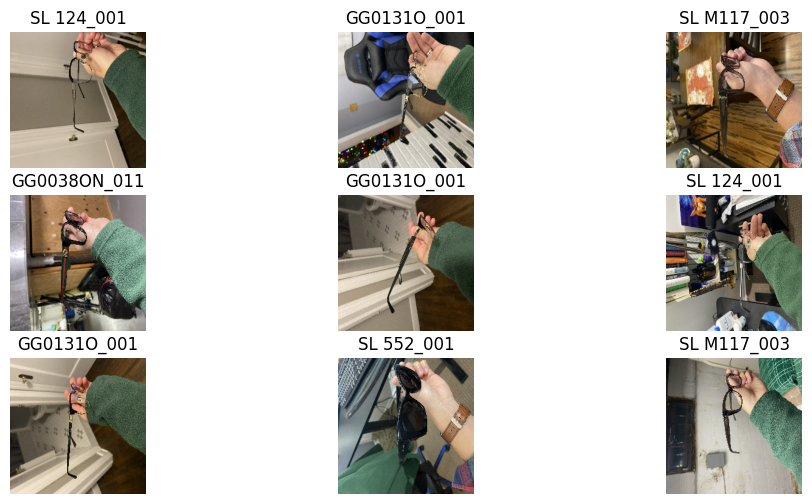

In [ ]:
import matplotlib.pyplot as plt


# Visualize a batch of validation images

for images, labels in val_ds.take(1):
    plt.figure(figsize=(12,6))
    for i in range(min(9, images.shape[0])):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()